In [1]:
import numpy as np
import matplotlib.pyplot as plt

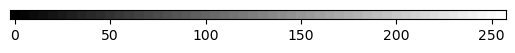

In [7]:
# Plotting greyscale images with sampled pixels
pixels = np.arange(256, dtype=np.uint8)
sampled_pixels = pixels[::5]
image = sampled_pixels[np.newaxis, :]
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
# plt.axis('off')

tick_positions = np.arange(0, len(sampled_pixels), 50//5)  # every 10 original pixels
tick_labels = np.arange(0, 256, 50)
plt.xticks(tick_positions, tick_labels)
plt.yticks([])

plt.savefig("grayscale_row.png", dpi=300, bbox_inches='tight')
plt.show()

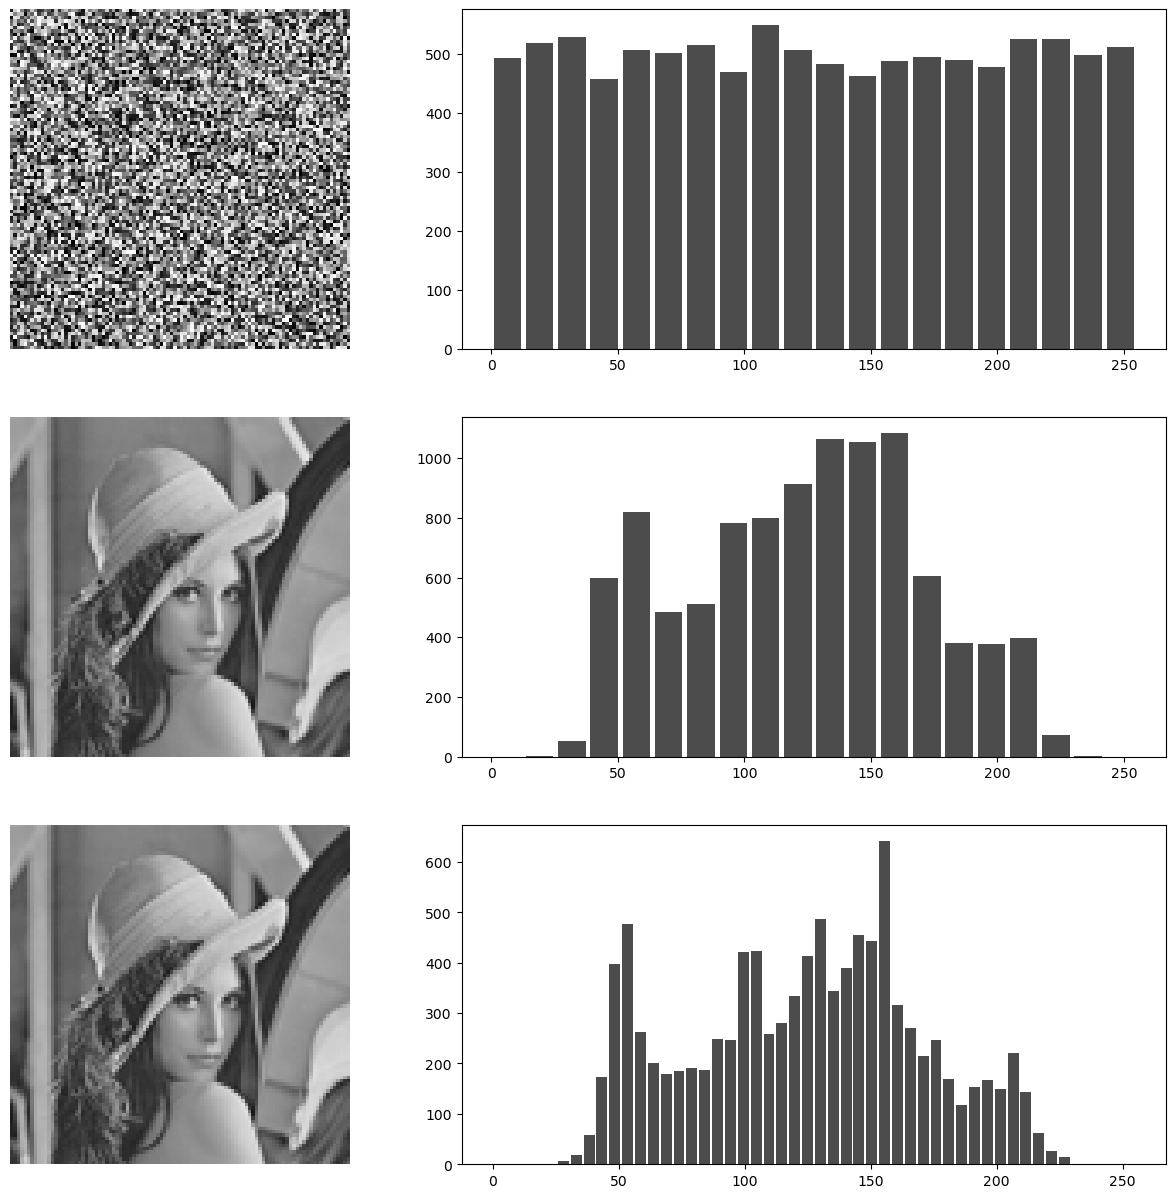

In [23]:
from matplotlib.gridspec import GridSpec
from PIL import Image
# Transforming an image to histogram
image = np.random.randint(0, 256, (100, 100), dtype=np.uint8)
lenna = Image.open('lena_std.tif').convert('L').resize((100, 100))
lenna = np.array(lenna)

# Total width = 5 + 10 = 15, height = 5
fig = plt.figure(figsize=(15, 15))

# Create a gridspec with 2 columns and widths ratio 1:2 (5 and 10)
gs = GridSpec(3, 2, width_ratios=[1, 2], figure=fig)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[3])
ax4 = fig.add_subplot(gs[4])
ax5 = fig.add_subplot(gs[5])

ax0.imshow(image, cmap='gray', vmin=0, vmax=255)
ax0.axis('off')

ax1.hist(image.ravel(), bins=20, range=(0, 255),
         color='black', alpha=0.7, rwidth=0.85)

ax2.imshow(lenna, cmap='gray', vmin=0, vmax=255)
ax2.axis('off')

ax3.hist(lenna.ravel(), bins=20, range=(0, 255),
            color='black', alpha=0.7, rwidth=0.85)

ax4.imshow(lenna, cmap='gray', vmin=0, vmax=255)
ax4.axis('off')
ax5.hist(lenna.ravel(), bins=50, range=(0, 255),
            color='black', alpha=0.7, rwidth=0.85)


plt.savefig('histogram.png', dpi=300, bbox_inches='tight')
plt.show()

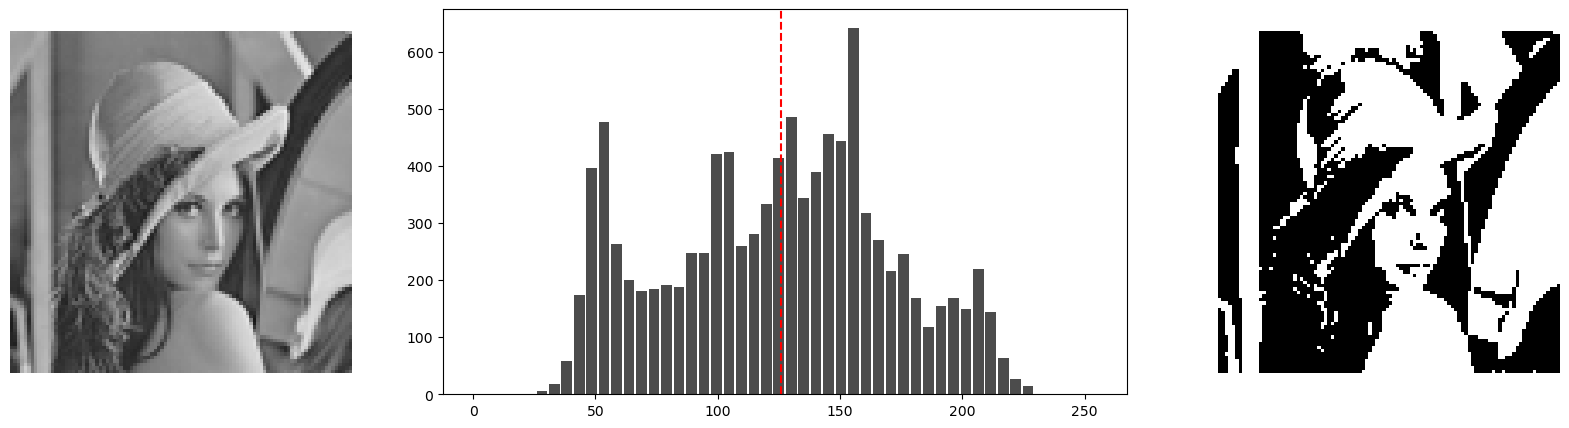

In [36]:
# Add a threshold to lenna to split the image
threshold = 126
binary_image = (lenna > threshold).astype(np.uint8)* 255

fig = plt.figure(figsize=(20, 5))
gs = GridSpec(1, 3, width_ratios=[1, 2, 1], figure=fig)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

ax0.imshow(lenna, cmap='gray', vmin=0, vmax=255)
ax0.axis('off')
ax1.hist(lenna.ravel(), bins=50, range=(0, 255),
            color='black', alpha=0.7, rwidth=0.85)
ax1.vlines(threshold, 0, 1, transform=ax1.get_xaxis_transform(), color='red', linestyle='--', label='Threshold')
ax2.imshow(binary_image, cmap='gray', vmin=0, vmax=255)
ax2.axis('off')

plt.axis('off')
plt.savefig('binary_image.png', dpi=300, bbox_inches='tight')
plt.show()